In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

In [2]:
df = pd.read_csv('soil.csv')

In [3]:
df.head()

,Soil1,Soil2
0,1.442,1.364
1,1.943,1.878
2,1.110,1.337
3,1.912,1.828
4,1.553,1.371


Checking if the data is normally distributed

In [4]:
Soil1 = pd.DataFrame(df.Soil1.dropna())

In [5]:
stats.shapiro(Soil1['Soil1'])

ShapiroResult(statistic=0.9605797529220581, pvalue=0.32050010561943054)

In [6]:
Soil2 = pd.DataFrame(df.Soil2.dropna())

In [7]:
stats.shapiro(Soil2['Soil2'])

ShapiroResult(statistic=0.9684141278266907, pvalue=0.40118902921676636)

Checking the Homogeneity of Variances

In [8]:
stats.levene(Soil1['Soil1'],Soil2['Soil2'])

LeveneResult(statistic=0.31486292982090475, pvalue=0.5767018253541134)

Applying T-Test

In [9]:
res = stats.ttest_ind(Soil1['Soil1'],Soil2['Soil2'],equal_var=True)
display(res)

Ttest_indResult(statistic=5.1681473319343345, pvalue=2.593228732352821e-06)

# Question 3

In [10]:
df1 = pd.read_csv('2015PISA.csv')

In [11]:
df1.head()

,Country Code,Continent_Code,internet_users_per_100,Math,Reading,Science
0,ALB,EU,63.252933,413.1570,405.2588,427.2250
1,ARE,AS,90.500000,427.4827,433.5423,436.7311
2,ARG,SA,68.043064,409.0333,425.3031,432.2262
3,AUS,OC,84.560519,493.8962,502.9006,509.9939
4,AUT,EU,83.940142,496.7423,484.8656,495.0375


In [12]:
df1['Continent_Code'].unique()

array(['EU', 'AS', 'SA', 'OC', nan, 'AF'], dtype=object)

In [13]:
df1 = df1.dropna()

In [14]:
df1['Continent_Code'].unique()

array(['EU', 'AS', 'SA', 'OC', 'AF'], dtype=object)

In [15]:
EU = df1.query('Continent_Code == "EU"')
AS = df1.query('Continent_Code == "AS"')
SA = df1.query('Continent_Code == "SA"')
OC = df1.query('Continent_Code == "OC"')
AF = df1.query('Continent_Code == "AF"')

Descriptive statistics with groupby

In [16]:
df1.groupby('Continent_Code').describe()

internet_users_per_100                                   \
                                count       mean        std        min   
Continent_Code                                                           
AF                                2.0  43.359918   7.297226  38.200000   
AS                               17.0  68.455613  21.086060  21.976068   
EU                               37.0  77.274888  12.425773  53.744979   
OC                                2.0  86.391704   2.589686  84.560519   
SA                                7.0  60.180494   9.772455  40.900000   

                                                            Math              \
                      25%        50%        75%        max count        mean   
Continent_Code                                                                 
AF              40.779959  43.359918  45.939877  48.519836   2.0  363.212100   
AS              50.300000  74.000000  84.948353  92.884826  17.0  466.216647   
EU              68.632900  76.184000  87.479056  98.200000  37.0  477.981449   
OC              85.476112  86.391704  87.307296  88.222889   2.0  494.559750   
SA              57.116462  64.289000  66.321532  69.198471   7.0  402.887700   

                ...     Reading           Science                         \
                ...         75%       max   count        mean        std   
Continent_Code  ...                                                        
AF              ...  358.256450  361.0555     2.0  381.074250   7.536556   
AS              ...  508.690500  535.1002    17.0  467.945847  56.671371   
EU              ...  499.814600  526.4247    37.0  478.299381  34.450616   
OC              ...  507.678175  509.2707     2.0  511.648700   2.340241   
SA              ...  431.922700  458.5709     7.0  421.747186  18.470319   

                                                                       
                     min         25%        50%         75%       max  
Continent_Code                                                         
AF              375.7451  378.409675  381.07425  383.738825  386.4034  
AS              386.4854  417.611200  456.48360  523.277400  555.5747  
EU              383.6824  460.774900  490.22500  501.936900  534.1937  
OC              509.9939  510.821300  511.64870  512.476100  513.3035  
SA              396.6836  408.205450  424.59050  433.794600  446.9561  

[5 rows x 32 columns]

Descriptive statistics one by one

In [17]:
EU.describe()

,internet_users_per_100,Math,Reading,Science
count,37.000000,37.000000,37.000000,37.000000
mean,77.274888,477.981449,476.164608,478.299381
std,12.425773,35.150403,37.720545,34.450616
min,53.744979,371.311400,351.741500,383.682400
25%,68.632900,464.040100,452.514300,460.774900
50%,76.184000,489.728700,487.250100,490.225000
75%,87.479056,503.722000,499.814600,501.936900
max,98.200000,521.250600,526.424700,534.193700


In [18]:
AS.describe()

,internet_users_per_100,Math,Reading,Science
count,17.000000,17.000000,17.000000,17.000000
mean,68.455613,466.216647,454.059682,467.945847
std,21.086060,64.356490,57.048962,56.671371
min,21.976068,380.259000,346.549000,386.485400
25%,50.300000,403.833200,408.102200,417.611200
50%,74.000000,459.816000,433.542300,456.483600
75%,84.948353,531.296100,508.690500,523.277400
max,92.884826,564.189700,535.100200,555.574700


In [19]:
SA.describe()

,internet_users_per_100,Math,Reading,Science
count,7.000000,7.000000,7.000000,7.000000
mean,60.180494,402.887700,425.359229,421.747186
std,9.772455,18.128894,19.709688,18.470319
min,40.900000,377.069500,397.541400,396.683600
25%,57.116462,388.102200,416.126900,408.205450
50%,64.289000,409.033300,425.303100,424.590500
75%,66.321532,417.617650,431.922700,433.794600
max,69.198471,422.671400,458.570900,446.956100


In [20]:
OC.describe()

,internet_users_per_100,Math,Reading,Science
count,2.000000,2.000000,2.000000,2.000000
mean,86.391704,494.559750,506.085650,511.648700
std,2.589686,0.938401,4.504341,2.340241
min,84.560519,493.896200,502.900600,509.993900
25%,85.476112,494.227975,504.493125,510.821300
50%,86.391704,494.559750,506.085650,511.648700
75%,87.307296,494.891525,507.678175,512.476100
max,88.222889,495.223300,509.270700,513.303500


In [21]:
AF.describe()

,internet_users_per_100,Math,Reading,Science
count,2.000000,2.000000,2.000000,2.000000
mean,43.359918,363.212100,355.457400,381.074250
std,7.297226,5.099513,7.916909,7.536556
min,38.200000,359.606200,349.859300,375.745100
25%,40.779959,361.409150,352.658350,378.409675
50%,43.359918,363.212100,355.457400,381.074250
75%,45.939877,365.015050,358.256450,383.738825
max,48.519836,366.818000,361.055500,386.403400


Distribution plots

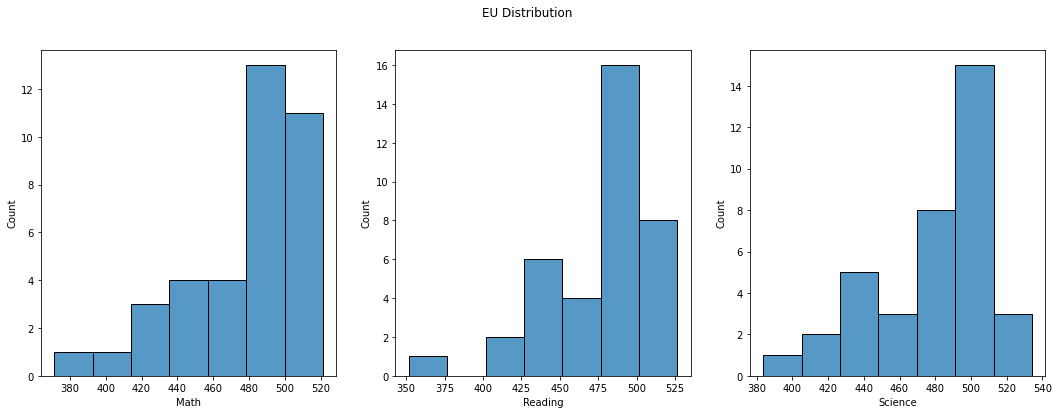

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(18,6))
sns.histplot(EU, x="Math", ax=ax1)
sns.histplot(EU, x="Reading", ax=ax2)
sns.histplot(EU, x="Science", ax=ax3)
plt.suptitle("EU Distribution")
plt.show()

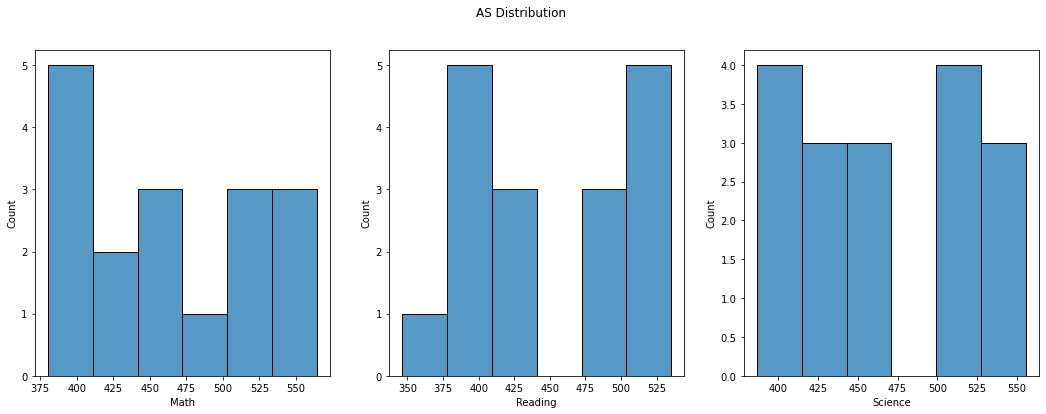

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(18,6))
sns.histplot(AS, x="Math", ax=ax1)
sns.histplot(AS, x="Reading", ax=ax2)
sns.histplot(AS, x="Science", ax=ax3)
plt.suptitle("AS Distribution")
plt.show()

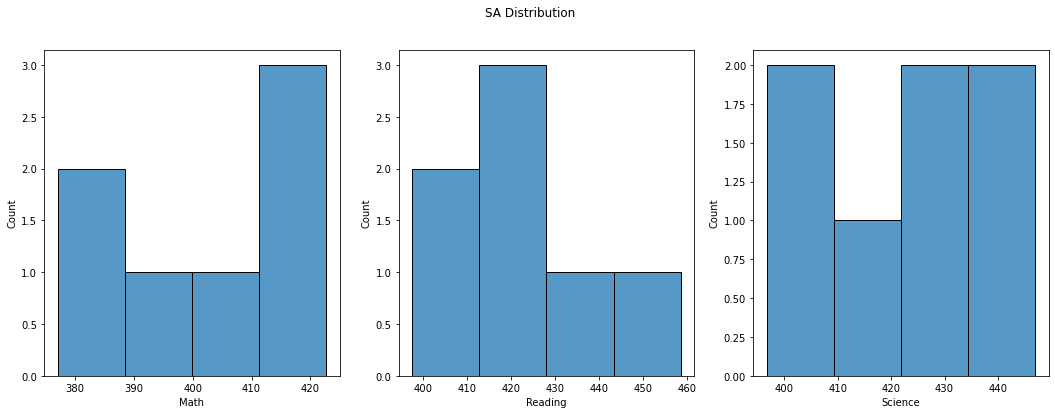

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(18,6))
sns.histplot(SA, x="Math", ax=ax1)
sns.histplot(SA, x="Reading", ax=ax2)
sns.histplot(SA, x="Science", ax=ax3)
plt.suptitle("SA Distribution")
plt.show()

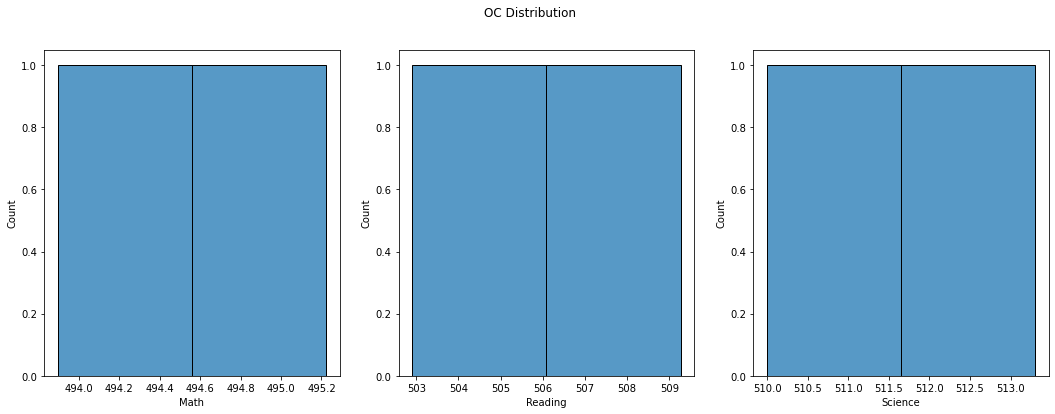

In [25]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(18,6))
sns.histplot(OC, x="Math", ax=ax1)
sns.histplot(OC, x="Reading", ax=ax2)
sns.histplot(OC, x="Science", ax=ax3)
plt.suptitle("OC Distribution")
plt.show()

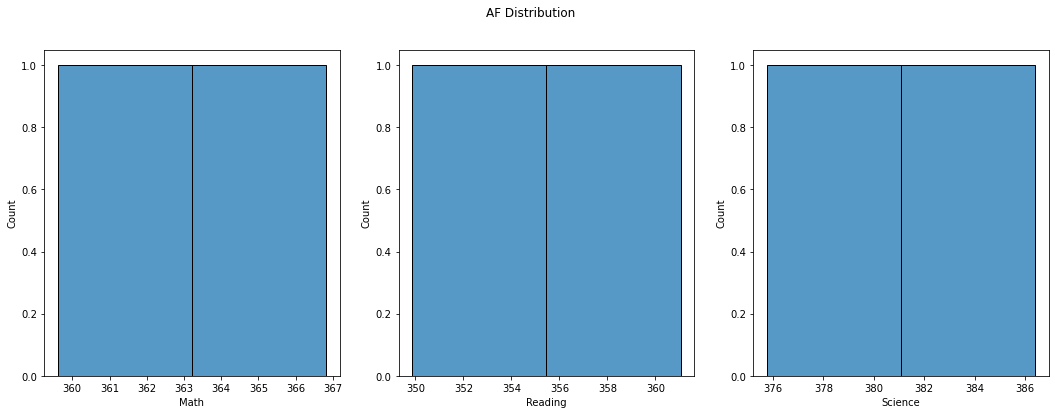

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(18,6))
sns.histplot(AF, x="Math", ax=ax1)
sns.histplot(AF, x="Reading", ax=ax2)
sns.histplot(AF, x="Science", ax=ax3)
plt.suptitle("AF Distribution")
plt.show()

part 2 of the question

In [27]:
res = stats.ttest_ind(EU['Math'],AS['Math'],equal_var=True)
display(res)

Ttest_indResult(statistic=0.870055317967983, pvalue=0.38826888111307345)

The p value is larger than alpha so we cannot reject null hyphoteses. It means there is ststistically meaningfull difference between EU Math mean and AS Math mean.

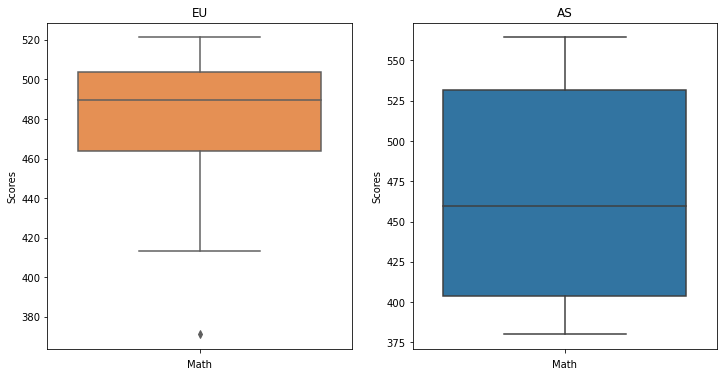

In [28]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
sns.boxplot(y=EU["Math"], ax=ax1, palette="Oranges").set(xlabel='Math', ylabel='Scores')
ax1.title.set_text('EU')
sns.boxplot(y=AS["Math"], ax=ax2).set(xlabel='Math', ylabel='Scores')
ax2.title.set_text('AS')
plt.show()

# Question 4

In [29]:
df2 = pd.read_csv('students_2014.csv')

In [30]:
df2.head()

,ids,bday,enrolldate,expgradate,Rank,Major,Gender,Athlete,Height,Weight,...,English,Reading,Math,Writing,State,LiveOnCampus,HowCommute,CommuteTime,SleepTime,StudyTime
0,43783,3/22/1995,NaN,NaN,NaN,NaN,0.0,0,72.35,NaN,...,88.24,81.50,60.02,81.44,In state,1.0,NaN,NaN,7.0,1.0
1,20278,1/1/1995,NaN,NaN,NaN,Philosophy,0.0,0,70.66,179.20,...,89.45,85.25,70.19,73.27,NaN,1.0,NaN,NaN,5.0,2.0
2,20389,12/31/1994,NaN,NaN,NaN,NaN,0.0,0,70.68,198.52,...,96.73,86.88,71.20,84.24,In state,NaN,NaN,NaN,8.0,7.0
3,22820,12/1/1994,NaN,NaN,NaN,business administration,1.0,0,NaN,198.34,...,74.06,88.68,55.89,73.16,In state,1.0,NaN,NaN,2.0,6.0
4,24559,11/10/1994,NaN,NaN,NaN,NaN,1.0,1,67.43,128.17,...,82.61,77.30,65.52,80.45,Out of state,1.0,NaN,NaN,7.0,3.0


In [31]:
math = pd.DataFrame(df2.Math.dropna())

In [38]:
math.mean()

Math    65.468009
dtype: float64

In [33]:
english = pd.DataFrame(df2.English.dropna())

In [39]:
english.mean()

English    82.787555
dtype: float64

In [34]:
stats.shapiro(math['Math'])

ShapiroResult(statistic=0.9952573776245117, pvalue=0.22645071148872375)

In [35]:
stats.shapiro(english['English'])

ShapiroResult(statistic=0.9965985417366028, pvalue=0.5434104800224304)

Both data are normally distributed.

In [36]:
stats.levene(math['Math'],english['English'])

LeveneResult(statistic=11.782061510895028, pvalue=0.0006276685732819104)

P is lees than alpha so we canot assume equal variances

In [37]:
res1 = stats.ttest_ind(math['Math'],english['English'],equal_var=False)
display(res)

Ttest_indResult(statistic=0.870055317967983, pvalue=0.38826888111307345)

P value is higher than alpha so there is statistically significant difference between matnh and english means.